# Doğal Dil İşleme Dersi Final Ödev-1

## Ürün Yorumları Üzerinde Ön İşleme ve Zipf Yasası Analizi

Bu çalışmada Kaggle üzerinden elde edilen Türkçe ürün yorumları veri seti kullanılmıştır. Amaç, gerçek dünya metin verileri üzerinde temel doğal dil işleme ön işleme adımlarını uygulamak, ham veri üzerinde Zipf Yasası analizini gerçekleştirmek ve model eğitimine hazır iki farklı veri seti üretmektir.

In [4]:
import pandas as pd

print("Pandas başarıyla yüklendi.")

Pandas başarıyla yüklendi.


In [6]:
import pandas as pd

df = pd.read_csv("HAM VERİ CLS XLS")

print(df.shape)
df.head()

(272216, 3)


,Rating (Star),Review,URL
0,5,3 yıldır tık demedi. :),https://www.hepsiburada.com/logitech-m175-kabl...
1,5,3 yıldır kullanıyorum müthiş,https://www.hepsiburada.com/logitech-m175-kabl...
2,4,Ürün bugün elime geçti çok fazla inceleme fırs...,https://www.hepsiburada.com/logitech-m175-kabl...
3,4,Almaya karar verdim. Hemencecik geldi. Keyifle...,https://www.hepsiburada.com/logitech-m175-kabl...
4,5,Günlük kullanımınızı çok çok iyi karsılıyor kı...,https://www.hepsiburada.com/logitech-m175-kabl...


# 1. Veri Setinin İlk İncelenmesi

Bu bölümde veri setinin boyutu, sütun yapısı ve ilk örnek kayıtları incelenmiştir.

Veri seti toplam 272.216 kullanıcı yorumu içermektedir.

Veri setindeki sütunlar:

- Rating (Star): Kullanıcının verdiği puan
- Review: Kullanıcı yorumu
- URL: Ürünün bağlantı adresi

Bu çalışma kapsamında doğal dil işleme işlemleri yalnızca Review sütunu üzerinde uygulanacaktır.

In [9]:
print("Veri Seti Boyutu:")
print(df.shape)

print("\nSütunlar:")
print(df.columns.tolist())

print("\nEksik Veri Kontrolü:")
print(df.isnull().sum())

Veri Seti Boyutu:
(272216, 3)

Sütunlar:
['Rating (Star)', 'Review', 'URL']

Eksik Veri Kontrolü:
Rating (Star)    0
Review           0
URL              0
dtype: int64


# 2. Ham Veri Örnekleri

Ön işleme işlemlerine başlamadan önce veri setinden bazı örnek yorumlar incelenmiştir. Bu sayede ham verinin yapısı gözlemlenmiştir.

In [12]:
df["Review"].head(10)

0                              3 yıldır tık demedi. :)
1                        3 yıldır kullanıyorum müthiş 
2    Ürün bugün elime geçti çok fazla inceleme fırs...
3    Almaya karar verdim. Hemencecik geldi. Keyifle...
4    Günlük kullanımınızı çok çok iyi karsılıyor kı...
5                                          gayet güzel
6    Çok kaliteli bir ürün ve fiyatı da uygun. Uzun...
7    yaklaşık 5 senedir kullanıyorum. defalarca düş...
8    evde oyuncu faresi kullanmaya alışkın olduğumd...
9    Ürün günlük kullanım için çok uygun. Ürünle bi...
Name: Review, dtype: object

### Ham Veri Gözlemleri

Ham veri incelendiğinde kullanıcı yorumlarının doğal dilde yazıldığı görülmektedir. Veri içerisinde:

- Büyük ve küçük harf farklılıkları bulunmaktadır.
- Noktalama işaretleri bulunmaktadır.
- Sayılar yer almaktadır.
- Emojiler ve özel karakterler bulunmaktadır.
- Yazım hataları ve günlük dil kullanımları bulunmaktadır.

Bu nedenle veri üzerinde çeşitli ön işleme adımlarının uygulanması gerekmektedir.

# 3. Zipf Yasası Analizi

Zipf Yasası, doğal dilde en sık kullanılan kelimelerin çok yüksek frekansa sahip olduğunu, kelime sıralaması ilerledikçe frekansların hızla azaldığını ifade eder.

Bu bölümde ham veri üzerinde Zipf Yasası incelenmiştir. Bunun için yorum metinlerindeki kelimelerin frekansları hesaplanmış ve log-log grafiği çizdirilmiştir.

In [16]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re

In [18]:
all_text = " ".join(df["Review"].astype(str))

print("Toplam karakter sayısı:")
print(len(all_text))

Toplam karakter sayısı:
45464012


In [20]:
words = re.findall(r'\w+', all_text.lower())

print("Toplam kelime sayısı:")
print(len(words))

print("\nİlk 20 kelime:")
print(words[:20])

Toplam kelime sayısı:
6595012

İlk 20 kelime:
['3', 'yıldır', 'tık', 'demedi', '3', 'yıldır', 'kullanıyorum', 'müthiş', 'ürün', 'bugün', 'elime', 'geçti', 'çok', 'fazla', 'inceleme', 'fırsatım', 'olmadı', 'ancak', 'gözüme', 'çarpan']


In [21]:
word_counts = Counter(words)

print("Benzersiz kelime sayısı:")
print(len(word_counts))

print("\nEn sık kullanılan 20 kelime:")
print(word_counts.most_common(20))


Benzersiz kelime sayısı:
226830

En sık kullanılan 20 kelime:
[('çok', 146915), ('bir', 146519), ('ve', 134223), ('ürün', 99869), ('bu', 82406), ('iyi', 67901), ('güzel', 58326), ('için', 57656), ('tavsiye', 53850), ('daha', 50919), ('ederim', 49159), ('ama', 48486), ('da', 38804), ('gayet', 36511), ('hızlı', 35111), ('de', 34752), ('aldım', 34714), ('teşekkürler', 33733), ('ürünü', 28743), ('gibi', 28546)]


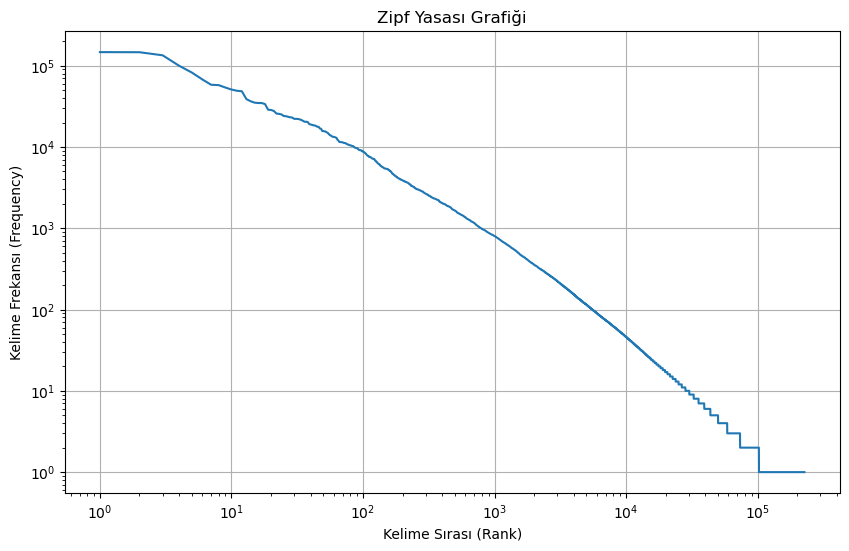

In [24]:
frequencies = sorted(word_counts.values(), reverse=True)

ranks = range(1, len(frequencies) + 1)

plt.figure(figsize=(10,6))
plt.loglog(ranks, frequencies)

plt.title("Zipf Yasası Grafiği")
plt.xlabel("Kelime Sırası (Rank)")
plt.ylabel("Kelime Frekansı (Frequency)")
plt.grid(True)

plt.show()


## Zipf Yasası Sonuçlarının Değerlendirilmesi

Oluşturulan log-log grafiği incelendiğinde, veri setindeki kelimelerin Zipf Yasasına uygun bir dağılım gösterdiği gözlemlenmiştir.

En sık kullanılan kelimeler oldukça yüksek frekanslara sahipken, kelime sıralaması ilerledikçe frekansların hızlı biçimde azaldığı görülmektedir.

Bu durum doğal dil verilerinde beklenen bir sonuçtur ve veri setinin gerçek kullanıcı yorumlarından oluştuğunu göstermektedir. Ayrıca ilerleyen aşamalarda uygulanacak stop word removal işleminin gerekli olduğunu da ortaya koymaktadır.

# 4. Veri Temizleme

Bu aşamada yorum metinlerinden doğal dil işleme açısından anlam taşımayan unsurlar temizlenmiştir.

Temizlenen öğeler:

- URL bağlantıları
- Sayılar
- Noktalama işaretleri
- Özel karakterler
- Fazladan boşluklar

Her işlem sonrasında verinin nasıl değiştiği örnekler üzerinden gösterilmiştir.

In [28]:
ornek_yorum = df["Review"].iloc[0]

print("TEMİZLEME ÖNCESİ:\n")
print(ornek_yorum)

TEMİZLEME ÖNCESİ:

3 yıldır tık demedi. :)


In [30]:
# URL, sayı, noktalama ve özel karakter temizliği

import re

def temizle(metin):

    # URL temizleme
    metin = re.sub(r'http\S+|www\S+', '', metin)

    # Sayıları temizleme
    metin = re.sub(r'\d+', '', metin)

    # Noktalama ve özel karakter temizleme
    metin = re.sub(r'[^\w\s]', '', metin)

    # Fazla boşlukları temizleme
    metin = re.sub(r'\s+', ' ', metin)

    return metin.strip()


temiz_yorum = temizle(ornek_yorum)

print("TEMİZLEME ÖNCESİ:\n")
print(ornek_yorum)

print("\nTEMİZLEME SONRASI:\n")
print(temiz_yorum)

TEMİZLEME ÖNCESİ:

3 yıldır tık demedi. :)

TEMİZLEME SONRASI:

yıldır tık demedi


## Temizlik Sonuçlarının Değerlendirilmesi

Temizlik işlemi sonrasında URL'ler, sayılar, noktalama işaretleri ve özel karakterler kaldırılmıştır.

Örnekte görüldüğü gibi "3" sayısı ve ":)" ifadesi temizlenmiş, yalnızca metnin anlam taşıyan kısmı bırakılmıştır.

Bu işlem model eğitiminde gürültüyü azaltmak ve daha kaliteli sonuçlar elde etmek amacıyla uygulanmıştır.

# 5. Lowercase İşlemi

Bu aşamada tüm metinler küçük harfe dönüştürülmüştür.

Büyük ve küçük harf farklılıklarının ortadan kaldırılması, aynı kelimenin farklı biçimlerde değerlendirilmesini engellemektedir.

Örneğin:

- Ürün
- ürün
- ÜRÜN

ifadeleri aynı kelime olarak değerlendirilmektedir.

In [34]:
ornek_buyuk = "ÜRÜN ÇOK GÜZEL VE KULLANIŞLI"

print("LOWERCASE ÖNCESİ:\n")
print(ornek_buyuk)

print("\nLOWERCASE SONRASI:\n")
print(ornek_buyuk.lower())

LOWERCASE ÖNCESİ:

ÜRÜN ÇOK GÜZEL VE KULLANIŞLI

LOWERCASE SONRASI:

ürün çok güzel ve kullanişli


In [36]:
# Temizlik işlemini tüm veri setine uygulama

df["clean_review"] = df["Review"].astype(str).apply(temizle)

print(df[["Review", "clean_review"]].head(10))

                                              Review  \
0                            3 yıldır tık demedi. :)   
1                      3 yıldır kullanıyorum müthiş    
2  Ürün bugün elime geçti çok fazla inceleme fırs...   
3  Almaya karar verdim. Hemencecik geldi. Keyifle...   
4  Günlük kullanımınızı çok çok iyi karsılıyor kı...   
5                                        gayet güzel   
6  Çok kaliteli bir ürün ve fiyatı da uygun. Uzun...   
7  yaklaşık 5 senedir kullanıyorum. defalarca düş...   
8  evde oyuncu faresi kullanmaya alışkın olduğumd...   
9  Ürün günlük kullanım için çok uygun. Ürünle bi...   

                                        clean_review  
0                                  yıldır tık demedi  
1                         yıldır kullanıyorum müthiş  
2  Ürün bugün elime geçti çok fazla inceleme fırs...  
3  Almaya karar verdim Hemencecik geldi Keyifle k...  
4  Günlük kullanımınızı çok çok iyi karsılıyor kı...  
5                                        gayet güzel 

In [37]:
pd.set_option('display.max_colwidth', None)

df[["Review", "clean_review"]].head(10)

,Review,clean_review
0,3 yıldır tık demedi. :),yıldır tık demedi
1,3 yıldır kullanıyorum müthiş,yıldır kullanıyorum müthiş
2,"Ürün bugün elime geçti çok fazla inceleme fırsatım olmadı ancak gözüme çarpan ilk şey usb bağlantısı için pil kapağının altında çok güzel yer yapmış olmaları, daha önceden o aparatı kaybetmiş biri olarak bu özelliğini çok sevdim. Ayrıca 1000dpi olması çok iyi bu tip farelerin çoğu 800dpi oluyor. Eğer sizde benim gibi masaüstü bilgisayarınızdan oyuncu faresi ile yüksek dpi ayarına alışmış biriyseniz windows ayarından fareyi en hızlıya getirin ve bu fareyi sipariş verin pişman olmazsınız. Teşekkürler Logitech",Ürün bugün elime geçti çok fazla inceleme fırsatım olmadı ancak gözüme çarpan ilk şey usb bağlantısı için pil kapağının altında çok güzel yer yapmış olmaları daha önceden o aparatı kaybetmiş biri olarak bu özelliğini çok sevdim Ayrıca dpi olması çok iyi bu tip farelerin çoğu dpi oluyor Eğer sizde benim gibi masaüstü bilgisayarınızdan oyuncu faresi ile yüksek dpi ayarına alışmış biriyseniz windows ayarından fareyi en hızlıya getirin ve bu fareyi sipariş verin pişman olmazsınız Teşekkürler Logitech
3,Almaya karar verdim. Hemencecik geldi. Keyifle kullanıyorum,Almaya karar verdim Hemencecik geldi Keyifle kullanıyorum
4,Günlük kullanımınızı çok çok iyi karsılıyor kısaca mükemmel,Günlük kullanımınızı çok çok iyi karsılıyor kısaca mükemmel
5,gayet güzel,gayet güzel
6,Çok kaliteli bir ürün ve fiyatı da uygun. Uzun araştırmalarım sonucu aldım ve çok memnunum.,Çok kaliteli bir ürün ve fiyatı da uygun Uzun araştırmalarım sonucu aldım ve çok memnunum
7,yaklaşık 5 senedir kullanıyorum. defalarca düşmesine rağmen banamısın demedi. 5 yıl daha gider diye düşünüyorum.,yaklaşık senedir kullanıyorum defalarca düşmesine rağmen banamısın demedi yıl daha gider diye düşünüyorum
8,evde oyuncu faresi kullanmaya alışkın olduğumdan genelde çok hızlı bir ayarda kullanıyorum fareyi. Bunu iş yerimde kablosuz olduğu için tercih ettim. Eğer benim gibi fareyi hızlı kullanmaya alışıksanız yavaş gelecektir ayrıca hassasiyetide çok üst düzey gelmedi bana. Basit işler için kullanacağınız ucuz bir kablosuz fare arıyorsanız işinizi görecektir.,evde oyuncu faresi kullanmaya alışkın olduğumdan genelde çok hızlı bir ayarda kullanıyorum fareyi Bunu iş yerimde kablosuz olduğu için tercih ettim Eğer benim gibi fareyi hızlı kullanmaya alışıksanız yavaş gelecektir ayrıca hassasiyetide çok üst düzey gelmedi bana Basit işler için kullanacağınız ucuz bir kablosuz fare arıyorsanız işinizi görecektir
9,Ürün günlük kullanım için çok uygun. Ürünle birlikte 1 adet pil de çıkıyor. İş ve günlük kullanım için Kablosuz mouse isteyenler düşünmeden alabilir. Haftanın 5 günü yaklaşık 8 saat kullanımda 2 ay civarında pil ömrü var.,Ürün günlük kullanım için çok uygun Ürünle birlikte adet pil de çıkıyor İş ve günlük kullanım için Kablosuz mouse isteyenler düşünmeden alabilir Haftanın günü yaklaşık saat kullanımda ay civarında pil ömrü var


### Temizlik Sonrası Örnekler

Aşağıdaki tabloda ilk 10 yorum için temizlik işlemi öncesi ve sonrası sonuçlar gösterilmektedir.

Tablo incelendiğinde sayıların, noktalama işaretlerinin ve özel karakterlerin başarıyla kaldırıldığı görülmektedir.

In [41]:
# Lowercase işlemini tüm veri setine uygulama

df["lower_review"] = df["clean_review"].str.lower()

df[["clean_review", "lower_review"]].head(10)

,clean_review,lower_review
0,yıldır tık demedi,yıldır tık demedi
1,yıldır kullanıyorum müthiş,yıldır kullanıyorum müthiş
2,Ürün bugün elime geçti çok fazla inceleme fırsatım olmadı ancak gözüme çarpan ilk şey usb bağlantısı için pil kapağının altında çok güzel yer yapmış olmaları daha önceden o aparatı kaybetmiş biri olarak bu özelliğini çok sevdim Ayrıca dpi olması çok iyi bu tip farelerin çoğu dpi oluyor Eğer sizde benim gibi masaüstü bilgisayarınızdan oyuncu faresi ile yüksek dpi ayarına alışmış biriyseniz windows ayarından fareyi en hızlıya getirin ve bu fareyi sipariş verin pişman olmazsınız Teşekkürler Logitech,ürün bugün elime geçti çok fazla inceleme fırsatım olmadı ancak gözüme çarpan ilk şey usb bağlantısı için pil kapağının altında çok güzel yer yapmış olmaları daha önceden o aparatı kaybetmiş biri olarak bu özelliğini çok sevdim ayrıca dpi olması çok iyi bu tip farelerin çoğu dpi oluyor eğer sizde benim gibi masaüstü bilgisayarınızdan oyuncu faresi ile yüksek dpi ayarına alışmış biriyseniz windows ayarından fareyi en hızlıya getirin ve bu fareyi sipariş verin pişman olmazsınız teşekkürler logitech
3,Almaya karar verdim Hemencecik geldi Keyifle kullanıyorum,almaya karar verdim hemencecik geldi keyifle kullanıyorum
4,Günlük kullanımınızı çok çok iyi karsılıyor kısaca mükemmel,günlük kullanımınızı çok çok iyi karsılıyor kısaca mükemmel
5,gayet güzel,gayet güzel
6,Çok kaliteli bir ürün ve fiyatı da uygun Uzun araştırmalarım sonucu aldım ve çok memnunum,çok kaliteli bir ürün ve fiyatı da uygun uzun araştırmalarım sonucu aldım ve çok memnunum
7,yaklaşık senedir kullanıyorum defalarca düşmesine rağmen banamısın demedi yıl daha gider diye düşünüyorum,yaklaşık senedir kullanıyorum defalarca düşmesine rağmen banamısın demedi yıl daha gider diye düşünüyorum
8,evde oyuncu faresi kullanmaya alışkın olduğumdan genelde çok hızlı bir ayarda kullanıyorum fareyi Bunu iş yerimde kablosuz olduğu için tercih ettim Eğer benim gibi fareyi hızlı kullanmaya alışıksanız yavaş gelecektir ayrıca hassasiyetide çok üst düzey gelmedi bana Basit işler için kullanacağınız ucuz bir kablosuz fare arıyorsanız işinizi görecektir,evde oyuncu faresi kullanmaya alışkın olduğumdan genelde çok hızlı bir ayarda kullanıyorum fareyi bunu iş yerimde kablosuz olduğu için tercih ettim eğer benim gibi fareyi hızlı kullanmaya alışıksanız yavaş gelecektir ayrıca hassasiyetide çok üst düzey gelmedi bana basit işler için kullanacağınız ucuz bir kablosuz fare arıyorsanız işinizi görecektir
9,Ürün günlük kullanım için çok uygun Ürünle birlikte adet pil de çıkıyor İş ve günlük kullanım için Kablosuz mouse isteyenler düşünmeden alabilir Haftanın günü yaklaşık saat kullanımda ay civarında pil ömrü var,ürün günlük kullanım için çok uygun ürünle birlikte adet pil de çıkıyor i̇ş ve günlük kullanım için kablosuz mouse isteyenler düşünmeden alabilir haftanın günü yaklaşık saat kullanımda ay civarında pil ömrü var


## Lowercase Sonuçlarının Değerlendirilmesi

Lowercase işlemi sonrasında tüm metinler küçük harfe dönüştürülmüştür.

Bu işlem sayesinde aynı kelimenin farklı yazım biçimleri tek bir form altında toplanmıştır.

Örneğin:

- Ürün
- ürün
- ÜRÜN

ifadeleri artık aynı kelime olarak değerlendirilmektedir.

Aşağıdaki tabloda ilk 10 yorum için lowercase işlemi öncesi ve sonrası sonuçları gösterilmektedir.

# 6. Tokenization İşlemi

Tokenization işlemi, metinlerin kelimelere ayrılması işlemidir.

Bu işlem sayesinde metinler doğal dil işleme algoritmalarının kullanabileceği kelime listelerine dönüştürülmektedir.

Aşağıda örnek bir yorum için tokenization işlemi öncesi ve sonrası gösterilmiştir.

In [45]:
ornek_token = df["lower_review"].iloc[0]

print("TOKENIZATION ÖNCESİ:\n")
print(ornek_token)

print("\nTOKENIZATION SONRASI:\n")
print(ornek_token.split())

TOKENIZATION ÖNCESİ:

yıldır tık demedi

TOKENIZATION SONRASI:

['yıldır', 'tık', 'demedi']


## Tokenization Sonuçlarının Değerlendirilmesi

Tokenization işlemi sonucunda yorum metni kelime parçalarına ayrılmıştır.

Bu işlem sonrasında her yorum, kelimelerden oluşan bir liste haline gelmiştir. Böylece stop word removal, lemmatization ve stemming işlemlerinin uygulanması mümkün hale gelmiştir.

In [48]:
# Tüm veri setine tokenization uygulama

df["tokens"] = df["lower_review"].apply(lambda x: x.split())

df[["lower_review", "tokens"]].head(10)

,lower_review,tokens
0,yıldır tık demedi,"[yıldır, tık, demedi]"
1,yıldır kullanıyorum müthiş,"[yıldır, kullanıyorum, müthiş]"
2,ürün bugün elime geçti çok fazla inceleme fırsatım olmadı ancak gözüme çarpan ilk şey usb bağlantısı için pil kapağının altında çok güzel yer yapmış olmaları daha önceden o aparatı kaybetmiş biri olarak bu özelliğini çok sevdim ayrıca dpi olması çok iyi bu tip farelerin çoğu dpi oluyor eğer sizde benim gibi masaüstü bilgisayarınızdan oyuncu faresi ile yüksek dpi ayarına alışmış biriyseniz windows ayarından fareyi en hızlıya getirin ve bu fareyi sipariş verin pişman olmazsınız teşekkürler logitech,"[ürün, bugün, elime, geçti, çok, fazla, inceleme, fırsatım, olmadı, ancak, gözüme, çarpan, ilk, şey, usb, bağlantısı, için, pil, kapağının, altında, çok, güzel, yer, yapmış, olmaları, daha, önceden, o, aparatı, kaybetmiş, biri, olarak, bu, özelliğini, çok, sevdim, ayrıca, dpi, olması, çok, iyi, bu, tip, farelerin, çoğu, dpi, oluyor, eğer, sizde, benim, gibi, masaüstü, bilgisayarınızdan, oyuncu, faresi, ile, yüksek, dpi, ayarına, alışmış, biriyseniz, windows, ayarından, fareyi, en, hızlıya, getirin, ve, bu, fareyi, sipariş, verin, pişman, olmazsınız, teşekkürler, logitech]"
3,almaya karar verdim hemencecik geldi keyifle kullanıyorum,"[almaya, karar, verdim, hemencecik, geldi, keyifle, kullanıyorum]"
4,günlük kullanımınızı çok çok iyi karsılıyor kısaca mükemmel,"[günlük, kullanımınızı, çok, çok, iyi, karsılıyor, kısaca, mükemmel]"
5,gayet güzel,"[gayet, güzel]"
6,çok kaliteli bir ürün ve fiyatı da uygun uzun araştırmalarım sonucu aldım ve çok memnunum,"[çok, kaliteli, bir, ürün, ve, fiyatı, da, uygun, uzun, araştırmalarım, sonucu, aldım, ve, çok, memnunum]"
7,yaklaşık senedir kullanıyorum defalarca düşmesine rağmen banamısın demedi yıl daha gider diye düşünüyorum,"[yaklaşık, senedir, kullanıyorum, defalarca, düşmesine, rağmen, banamısın, demedi, yıl, daha, gider, diye, düşünüyorum]"
8,evde oyuncu faresi kullanmaya alışkın olduğumdan genelde çok hızlı bir ayarda kullanıyorum fareyi bunu iş yerimde kablosuz olduğu için tercih ettim eğer benim gibi fareyi hızlı kullanmaya alışıksanız yavaş gelecektir ayrıca hassasiyetide çok üst düzey gelmedi bana basit işler için kullanacağınız ucuz bir kablosuz fare arıyorsanız işinizi görecektir,"[evde, oyuncu, faresi, kullanmaya, alışkın, olduğumdan, genelde, çok, hızlı, bir, ayarda, kullanıyorum, fareyi, bunu, iş, yerimde, kablosuz, olduğu, için, tercih, ettim, eğer, benim, gibi, fareyi, hızlı, kullanmaya, alışıksanız, yavaş, gelecektir, ayrıca, hassasiyetide, çok, üst, düzey, gelmedi, bana, basit, işler, için, kullanacağınız, ucuz, bir, kablosuz, fare, arıyorsanız, işinizi, görecektir]"
9,ürün günlük kullanım için çok uygun ürünle birlikte adet pil de çıkıyor i̇ş ve günlük kullanım için kablosuz mouse isteyenler düşünmeden alabilir haftanın günü yaklaşık saat kullanımda ay civarında pil ömrü var,"[ürün, günlük, kullanım, için, çok, uygun, ürünle, birlikte, adet, pil, de, çıkıyor, i̇ş, ve, günlük, kullanım, için, kablosuz, mouse, isteyenler, düşünmeden, alabilir, haftanın, günü, yaklaşık, saat, kullanımda, ay, civarında, pil, ömrü, var]"


## Tokenization İşleminin Tüm Veri Setine Uygulanması

Tokenization işlemi veri setindeki tüm yorumlara uygulanmıştır.

Bu işlem sonucunda yorum metinleri kelime listelerine dönüştürülmüştür.

Aşağıdaki tabloda ilk 10 yorum için tokenization öncesi ve sonrası sonuçlar gösterilmektedir.

In [51]:
import nltk

print("NLTK başarıyla yüklendi.")

NLTK başarıyla yüklendi.


In [53]:
import zeyrek

print("Zeyrek başarıyla yüklendi.")

Zeyrek başarıyla yüklendi.


# 7. Stop Word Removal

Stop word removal, metin içinde çok sık geçen ancak tek başına güçlü anlam taşımayan kelimelerin çıkarılması işlemidir.

Türkçe için "ve", "bir", "bu", "da", "de", "ile", "için" gibi kelimeler stop word olarak değerlendirilebilir.

Bu işlem, modelin daha anlamlı kelimelere odaklanmasını sağlar.


In [56]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

turkish_stopwords = set(stopwords.words("turkish"))

print("Türkçe stopword sayısı:", len(turkish_stopwords))
print("İlk 20 stopword:", list(turkish_stopwords)[:20])

Türkçe stopword sayısı: 53
İlk 20 stopword: ['o', 'şu', 'tüm', 'ki', 'daha', 'belki', 'ile', 'ya', 'ise', 'çünkü', 'diye', 'defa', 'bazı', 'hiç', 'nerede', 'sanki', 'hepsi', 'şey', 'mu', 'mü']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\EXCALIBUR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
ornek_stopword = df["tokens"].iloc[2]

print("STOPWORD REMOVAL ÖNCESİ:\n")
print(ornek_stopword)

ornek_stopword_sonrasi = [
    kelime for kelime in ornek_stopword
    if kelime not in turkish_stopwords
]

print("\nSTOPWORD REMOVAL SONRASI:\n")
print(ornek_stopword_sonrasi)

STOPWORD REMOVAL ÖNCESİ:

['ürün', 'bugün', 'elime', 'geçti', 'çok', 'fazla', 'inceleme', 'fırsatım', 'olmadı', 'ancak', 'gözüme', 'çarpan', 'ilk', 'şey', 'usb', 'bağlantısı', 'için', 'pil', 'kapağının', 'altında', 'çok', 'güzel', 'yer', 'yapmış', 'olmaları', 'daha', 'önceden', 'o', 'aparatı', 'kaybetmiş', 'biri', 'olarak', 'bu', 'özelliğini', 'çok', 'sevdim', 'ayrıca', 'dpi', 'olması', 'çok', 'iyi', 'bu', 'tip', 'farelerin', 'çoğu', 'dpi', 'oluyor', 'eğer', 'sizde', 'benim', 'gibi', 'masaüstü', 'bilgisayarınızdan', 'oyuncu', 'faresi', 'ile', 'yüksek', 'dpi', 'ayarına', 'alışmış', 'biriyseniz', 'windows', 'ayarından', 'fareyi', 'en', 'hızlıya', 'getirin', 've', 'bu', 'fareyi', 'sipariş', 'verin', 'pişman', 'olmazsınız', 'teşekkürler', 'logitech']

STOPWORD REMOVAL SONRASI:

['ürün', 'bugün', 'elime', 'geçti', 'fazla', 'inceleme', 'fırsatım', 'olmadı', 'ancak', 'gözüme', 'çarpan', 'ilk', 'usb', 'bağlantısı', 'pil', 'kapağının', 'altında', 'güzel', 'yer', 'yapmış', 'olmaları', 'önceden',

## Stop Word Removal Sonuçlarının Değerlendirilmesi

Stop word removal işlemi sonrasında anlam taşımayan ve çok sık kullanılan kelimeler veri setinden çıkarılmıştır.

Örneğin "ve", "bir", "bu", "da", "de", "ile", "için" gibi kelimeler kaldırılmıştır.

Bu işlem sayesinde model, yorumların anlamını taşıyan kelimelere daha fazla odaklanabilmektedir.

In [61]:
df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda kelimeler: [k for k in kelimeler if k not in turkish_stopwords]
)

df[["tokens", "tokens_no_stopwords"]].head(10)

,tokens,tokens_no_stopwords
0,"[yıldır, tık, demedi]","[yıldır, tık, demedi]"
1,"[yıldır, kullanıyorum, müthiş]","[yıldır, kullanıyorum, müthiş]"
2,"[ürün, bugün, elime, geçti, çok, fazla, inceleme, fırsatım, olmadı, ancak, gözüme, çarpan, ilk, şey, usb, bağlantısı, için, pil, kapağının, altında, çok, güzel, yer, yapmış, olmaları, daha, önceden, o, aparatı, kaybetmiş, biri, olarak, bu, özelliğini, çok, sevdim, ayrıca, dpi, olması, çok, iyi, bu, tip, farelerin, çoğu, dpi, oluyor, eğer, sizde, benim, gibi, masaüstü, bilgisayarınızdan, oyuncu, faresi, ile, yüksek, dpi, ayarına, alışmış, biriyseniz, windows, ayarından, fareyi, en, hızlıya, getirin, ve, bu, fareyi, sipariş, verin, pişman, olmazsınız, teşekkürler, logitech]","[ürün, bugün, elime, geçti, fazla, inceleme, fırsatım, olmadı, ancak, gözüme, çarpan, ilk, usb, bağlantısı, pil, kapağının, altında, güzel, yer, yapmış, olmaları, önceden, aparatı, kaybetmiş, olarak, özelliğini, sevdim, ayrıca, dpi, olması, iyi, tip, farelerin, çoğu, dpi, oluyor, sizde, benim, masaüstü, bilgisayarınızdan, oyuncu, faresi, yüksek, dpi, ayarına, alışmış, biriyseniz, windows, ayarından, fareyi, hızlıya, getirin, fareyi, sipariş, verin, pişman, olmazsınız, teşekkürler, logitech]"
3,"[almaya, karar, verdim, hemencecik, geldi, keyifle, kullanıyorum]","[almaya, karar, verdim, hemencecik, geldi, keyifle, kullanıyorum]"
4,"[günlük, kullanımınızı, çok, çok, iyi, karsılıyor, kısaca, mükemmel]","[günlük, kullanımınızı, iyi, karsılıyor, kısaca, mükemmel]"
5,"[gayet, güzel]","[gayet, güzel]"
6,"[çok, kaliteli, bir, ürün, ve, fiyatı, da, uygun, uzun, araştırmalarım, sonucu, aldım, ve, çok, memnunum]","[kaliteli, bir, ürün, fiyatı, uygun, uzun, araştırmalarım, sonucu, aldım, memnunum]"
7,"[yaklaşık, senedir, kullanıyorum, defalarca, düşmesine, rağmen, banamısın, demedi, yıl, daha, gider, diye, düşünüyorum]","[yaklaşık, senedir, kullanıyorum, defalarca, düşmesine, rağmen, banamısın, demedi, yıl, gider, düşünüyorum]"
8,"[evde, oyuncu, faresi, kullanmaya, alışkın, olduğumdan, genelde, çok, hızlı, bir, ayarda, kullanıyorum, fareyi, bunu, iş, yerimde, kablosuz, olduğu, için, tercih, ettim, eğer, benim, gibi, fareyi, hızlı, kullanmaya, alışıksanız, yavaş, gelecektir, ayrıca, hassasiyetide, çok, üst, düzey, gelmedi, bana, basit, işler, için, kullanacağınız, ucuz, bir, kablosuz, fare, arıyorsanız, işinizi, görecektir]","[evde, oyuncu, faresi, kullanmaya, alışkın, olduğumdan, genelde, hızlı, bir, ayarda, kullanıyorum, fareyi, bunu, iş, yerimde, kablosuz, olduğu, tercih, ettim, benim, fareyi, hızlı, kullanmaya, alışıksanız, yavaş, gelecektir, ayrıca, hassasiyetide, üst, düzey, gelmedi, bana, basit, işler, kullanacağınız, ucuz, bir, kablosuz, fare, arıyorsanız, işinizi, görecektir]"
9,"[ürün, günlük, kullanım, için, çok, uygun, ürünle, birlikte, adet, pil, de, çıkıyor, i̇ş, ve, günlük, kullanım, için, kablosuz, mouse, isteyenler, düşünmeden, alabilir, haftanın, günü, yaklaşık, saat, kullanımda, ay, civarında, pil, ömrü, var]","[ürün, günlük, kullanım, uygun, ürünle, birlikte, adet, pil, çıkıyor, i̇ş, günlük, kullanım, kablosuz, mouse, isteyenler, düşünmeden, alabilir, haftanın, günü, yaklaşık, saat, kullanımda, ay, civarında, pil, ömrü, var]"


In [63]:
print("Toplam yorum sayısı:", len(df))

print("Toplam kelime sayısı:", len(words))

print("Benzersiz kelime sayısı:", len(word_counts))

Toplam yorum sayısı: 272216
Toplam kelime sayısı: 6595012
Benzersiz kelime sayısı: 226830


In [65]:
analyzer = zeyrek.MorphAnalyzer()

kelime = "kullanıyorum"

sonuc = analyzer.lemmatize(kelime)

print(sonuc)

APPENDING RESULT: <(kullanmak_Verb)(-)(kullan:verbRoot_S + ıyor:vProgYor_S + um:vA1sg_ST)>
APPENDING RESULT: <(kul_Noun)(-)(kul:noun_S + a3sg_S + pnon_S + nom_ST + lan:acquire_S + verbRoot_S + ıyor:vProgYor_S + um:vA1sg_ST)>


[('kullanıyorum', ['kul', 'kullanmak'])]


# 8. Lemmatization İşlemi

Lemmatization işlemi, kelimelerin sözlükte bulunan temel biçimlerine dönüştürülmesi işlemidir.

Bu işlem sayesinde farklı çekim ekleri almış kelimeler ortak bir kök altında toplanmaktadır.

Örneğin:

- kullanıyorum
- kullandım
- kullanacak

ifadeleri "kullanmak" kökü altında birleştirilebilir.

In [68]:
ornek_lemma = "kullanıyorum"

lemma_sonuc = analyzer.lemmatize(ornek_lemma)

print("LEMMATIZATION ÖNCESİ:\n")
print(ornek_lemma)

print("\nLEMMATIZATION SONRASI:\n")
print(lemma_sonuc[0][1][0])

APPENDING RESULT: <(kullanmak_Verb)(-)(kullan:verbRoot_S + ıyor:vProgYor_S + um:vA1sg_ST)>
APPENDING RESULT: <(kul_Noun)(-)(kul:noun_S + a3sg_S + pnon_S + nom_ST + lan:acquire_S + verbRoot_S + ıyor:vProgYor_S + um:vA1sg_ST)>


LEMMATIZATION ÖNCESİ:

kullanıyorum

LEMMATIZATION SONRASI:

kul


In [70]:
# Bilgisayarı yormamak için veri setinden dengeli bir örneklem alma

df_sample = df.sample(n=30000, random_state=42).reset_index(drop=True)

print("Orijinal veri boyutu:", df.shape)
print("Kullanılacak örnek veri boyutu:", df_sample.shape)

df_sample.head()

Orijinal veri boyutu: (272216, 7)
Kullanılacak örnek veri boyutu: (30000, 7)


,Rating (Star),Review,URL,clean_review,lower_review,tokens,tokens_no_stopwords
0,5,Ürün güzel sadece puan vermek için yorum yazmak istedim tavsiye ederim kesinlikle denilen sürede geldi ve olduğu gibi geldi teşekkürler hepsi burada,https://www.hepsiburada.com/prima-bebek-bezi-aktif-bebek-5-beden-junior-ultra-firsat-paketi112-adet-p-ZYPYON7376120,Ürün güzel sadece puan vermek için yorum yazmak istedim tavsiye ederim kesinlikle denilen sürede geldi ve olduğu gibi geldi teşekkürler hepsi burada,ürün güzel sadece puan vermek için yorum yazmak istedim tavsiye ederim kesinlikle denilen sürede geldi ve olduğu gibi geldi teşekkürler hepsi burada,"[ürün, güzel, sadece, puan, vermek, için, yorum, yazmak, istedim, tavsiye, ederim, kesinlikle, denilen, sürede, geldi, ve, olduğu, gibi, geldi, teşekkürler, hepsi, burada]","[ürün, güzel, sadece, puan, vermek, yorum, yazmak, istedim, tavsiye, ederim, kesinlikle, denilen, sürede, geldi, olduğu, geldi, teşekkürler, burada]"
1,5,sıfır sinek kaydı bir traj beklentiniz olacaksa bunu almayın.. ama kirli sakal ya da çok uzamış sakalı rahatlıkla kesiyor.. hızlı pratik 1 saatlik şarjla yaklaşık 50 dakka civarı gidiyor.. tek dezavantajı elektrikle direk çalışmaması.. muhakkak şarjlı olarak çalışması.,https://www.hepsiburada.com/philips-7000-serisi-multigroom-qg3380-16-erkek-bakim-seti-10-u-1-arada-p-SGPHQG3380,sıfır sinek kaydı bir traj beklentiniz olacaksa bunu almayın ama kirli sakal ya da çok uzamış sakalı rahatlıkla kesiyor hızlı pratik saatlik şarjla yaklaşık dakka civarı gidiyor tek dezavantajı elektrikle direk çalışmaması muhakkak şarjlı olarak çalışması,sıfır sinek kaydı bir traj beklentiniz olacaksa bunu almayın ama kirli sakal ya da çok uzamış sakalı rahatlıkla kesiyor hızlı pratik saatlik şarjla yaklaşık dakka civarı gidiyor tek dezavantajı elektrikle direk çalışmaması muhakkak şarjlı olarak çalışması,"[sıfır, sinek, kaydı, bir, traj, beklentiniz, olacaksa, bunu, almayın, ama, kirli, sakal, ya, da, çok, uzamış, sakalı, rahatlıkla, kesiyor, hızlı, pratik, saatlik, şarjla, yaklaşık, dakka, civarı, gidiyor, tek, dezavantajı, elektrikle, direk, çalışmaması, muhakkak, şarjlı, olarak, çalışması]","[sıfır, sinek, kaydı, bir, traj, beklentiniz, olacaksa, bunu, almayın, kirli, sakal, uzamış, sakalı, rahatlıkla, kesiyor, hızlı, pratik, saatlik, şarjla, yaklaşık, dakka, civarı, gidiyor, tek, dezavantajı, elektrikle, direk, çalışmaması, muhakkak, şarjlı, olarak, çalışması]"
2,5,Ürünü bende yorumları okuduktan sonra aldım lastik indi ve kullandım sibop dan kaçırıyordu.kullanışlı bi o kadarda gerekli oldugunu dusunuyorum. ılgılenenler kacırmasın ben yıne sıparısımı verdim. arabamda kalsın ihtiyac olur birgün. herkese tavsiye ediyorum,https://www.hepsiburada.com/stac-italy-patlak-lastigi-sisiren-ve-tamir-eden-sprey-091153-p-OTM091153,Ürünü bende yorumları okuduktan sonra aldım lastik indi ve kullandım sibop dan kaçırıyordukullanışlı bi o kadarda gerekli oldugunu dusunuyorum ılgılenenler kacırmasın ben yıne sıparısımı verdim arabamda kalsın ihtiyac olur birgün herkese tavsiye ediyorum,ürünü bende yorumları okuduktan sonra aldım lastik indi ve kullandım sibop dan kaçırıyordukullanışlı bi o kadarda gerekli oldugunu dusunuyorum ılgılenenler kacırmasın ben yıne sıparısımı verdim arabamda kalsın ihtiyac olur birgün herkese tavsiye ediyorum,"[ürünü, bende, yorumları, okuduktan, sonra, aldım, lastik, indi, ve, kullandım, sibop, dan, kaçırıyordukullanışlı, bi, o, kadarda, gerekli, oldugunu, dusunuyorum, ılgılenenler, kacırmasın, ben, yıne, sıparısımı, verdim, arabamda, kalsın, ihtiyac, olur, birgün, herkese, tavsiye, ediyorum]","[ürünü, bende, yorumları, okuduktan, sonra, aldım, lastik, indi, kullandım, sibop, dan, kaçırıyordukullanışlı, bi, kadarda, gerekli, oldugunu, dusunuyorum, ılgılenenler, kacırmasın, ben, yıne, sıparısımı, verdim, arabamda, kalsın, ihtiyac, olur, birgün, herkese, tavsiye, ediyorum]"
3,5,Tam aradığım ürünü buldum fiyat ve performans oldukça güzel kaliteli bir ürün tavsiye ederim,https://www.h

In [72]:
def get_lemma(word):
    try:
        sonuc = analyzer.lemmatize(word)

        if sonuc and len(sonuc[0][1]) > 0:
            return sonuc[0][1][0]

        return word

    except:
        return word

In [74]:
print(get_lemma("kullanıyorum"))
print(get_lemma("geldim"))
print(get_lemma("oynuyorum"))

APPENDING RESULT: <(kullanmak_Verb)(-)(kullan:verbRoot_S + ıyor:vProgYor_S + um:vA1sg_ST)>
APPENDING RESULT: <(kul_Noun)(-)(kul:noun_S + a3sg_S + pnon_S + nom_ST + lan:acquire_S + verbRoot_S + ıyor:vProgYor_S + um:vA1sg_ST)>
APPENDING RESULT: <(gelmek_Verb)(-)(gel:verbRoot_S + di:vPast_S + m:vA1sg_ST)>
APPENDING RESULT: <(oynamak_Verb)(-)(oyn:verbRoot_VowelDrop_S + uyor:vProgYor_S + um:vA1sg_ST)>


kul
gelmek
oynamak


In [76]:
print(df_sample.shape)

(30000, 7)


In [78]:
df_sample = df.sample(n=10000, random_state=42).reset_index(drop=True)

print("Kullanılacak örnek veri boyutu:", df_sample.shape)

Kullanılacak örnek veri boyutu: (10000, 7)


In [80]:
lemma_cache = {}

def get_lemma_fast(word):
    if word in lemma_cache:
        return lemma_cache[word]
    
    try:
        sonuc = analyzer.lemmatize(word)
        if sonuc and len(sonuc[0][1]) > 0:
            lemma = sonuc[0][1][0]
        else:
            lemma = word
    except:
        lemma = word
    
    lemma_cache[word] = lemma
    return lemma

In [83]:
df_sample["lemmatized_tokens"] = df_sample["tokens_no_stopwords"].apply(
    lambda kelimeler: [get_lemma_fast(k) for k in kelimeler]
)

df_sample[["tokens_no_stopwords", "lemmatized_tokens"]].head(5)

,tokens_no_stopwords,lemmatized_tokens
0,"[ürün, güzel, sadece, puan, vermek, yorum, yazmak, istedim, tavsiye, ederim, kesinlikle, denilen, sürede, geldi, olduğu, geldi, teşekkürler, burada]","[ürün, güzel, Sade, puan, vermek, yorum, yazmak, istemek, tavsiye, eder, kesinlikle, deni, süre, gelmek, olmak, gelmek, teşekkür, bura]"
1,"[sıfır, sinek, kaydı, bir, traj, beklentiniz, olacaksa, bunu, almayın, kirli, sakal, uzamış, sakalı, rahatlıkla, kesiyor, hızlı, pratik, saatlik, şarjla, yaklaşık, dakka, civarı, gidiyor, tek, dezavantajı, elektrikle, direk, çalışmaması, muhakkak, şarjlı, olarak, çalışması]","[sıfır, sinek, kaymak, bir, traj, beklenti, olmak, bu, almak, kir, sakal, uzamak, sakal, rahatlıkla, kesmek, hız, pratik, saat, şarj, yaklaşık, Dakka, civar, gitmek, tek, dezavantaj, Elektrik, direk, çalışmak, muhakkak, şarj, olmak, çalışmak]"
2,"[ürünü, bende, yorumları, okuduktan, sonra, aldım, lastik, indi, kullandım, sibop, dan, kaçırıyordukullanışlı, bi, kadarda, gerekli, oldugunu, dusunuyorum, ılgılenenler, kacırmasın, ben, yıne, sıparısımı, verdim, arabamda, kalsın, ihtiyac, olur, birgün, herkese, tavsiye, ediyorum]","[ürün, ben, yorum, okumak, sonra, Al, lastik, inmek, kul, sibop, dan, kaçırıyordukullanışlı, bi, Kadar, gerek, oldugunu, dusunuyorum, ılgılenenler, kacırmasın, ben, yıne, sıparısımı, verdi, araba, kal, ihtiyac, Olur, birgün, herkes, tavsiye, etmek]"
3,"[tam, aradığım, ürünü, buldum, fiyat, performans, oldukça, güzel, kaliteli, bir, ürün, tavsiye, ederim]","[tam, aramak, ürün, bul, fiyat, performans, oldukça, güzel, kalite, bir, ürün, tavsiye, eder]"
4,"[fiyat, olarakkargo, ücretsiz, olanlar, arasında, iyi, fiyat, kalite, güsel]","[fiyat, olarakkargo, ücret, olmak, Aras, iyi, fiyat, kalite, Gü]"


In [85]:
print("Örnek Lemmatization Sonuçları:\n")

for i in range(5):
    print("ÖNCE:")
    print(df_sample["tokens_no_stopwords"].iloc[i])

    print("\nSONRA:")
    print(df_sample["lemmatized_tokens"].iloc[i])

    print("\n" + "="*80 + "\n")

Örnek Lemmatization Sonuçları:

ÖNCE:
['ürün', 'güzel', 'sadece', 'puan', 'vermek', 'yorum', 'yazmak', 'istedim', 'tavsiye', 'ederim', 'kesinlikle', 'denilen', 'sürede', 'geldi', 'olduğu', 'geldi', 'teşekkürler', 'burada']

SONRA:
['ürün', 'güzel', 'Sade', 'puan', 'vermek', 'yorum', 'yazmak', 'istemek', 'tavsiye', 'eder', 'kesinlikle', 'deni', 'süre', 'gelmek', 'olmak', 'gelmek', 'teşekkür', 'bura']


ÖNCE:
['sıfır', 'sinek', 'kaydı', 'bir', 'traj', 'beklentiniz', 'olacaksa', 'bunu', 'almayın', 'kirli', 'sakal', 'uzamış', 'sakalı', 'rahatlıkla', 'kesiyor', 'hızlı', 'pratik', 'saatlik', 'şarjla', 'yaklaşık', 'dakka', 'civarı', 'gidiyor', 'tek', 'dezavantajı', 'elektrikle', 'direk', 'çalışmaması', 'muhakkak', 'şarjlı', 'olarak', 'çalışması']

SONRA:
['sıfır', 'sinek', 'kaymak', 'bir', 'traj', 'beklenti', 'olmak', 'bu', 'almak', 'kir', 'sakal', 'uzamak', 'sakal', 'rahatlıkla', 'kesmek', 'hız', 'pratik', 'saat', 'şarj', 'yaklaşık', 'Dakka', 'civar', 'gitmek', 'tek', 'dezavantaj', 'Elektrik

Lemmatization işlemi sonucunda kelimeler sözlükteki temel biçimlerine dönüştürülmüştür.

Örneğin "geldi" kelimesi "gelmek", "yazmak istedim" ifadesindeki "istedim" kelimesi "istemek" biçimine dönüştürülmüştür.

Bu işlem sayesinde aynı anlamı taşıyan farklı çekimlerdeki kelimeler ortak kök altında toplanmış ve veri setindeki kelime çeşitliliği azaltılmıştır.

Bu durum makine öğrenmesi modellerinin daha tutarlı ve doğru sonuçlar üretmesine katkı sağlamaktadır.

# 9. Stemming İşlemi

Stemming işlemi, kelimelerin eklerinden arındırılarak gövde (stem) haline dönüştürülmesidir.

Lemmatization işleminden farklı olarak stemming, kelimenin sözlük karşılığını bulmaya çalışmaz; yalnızca ekleri kaldırarak daha kısa bir kök üretir.

Bu işlem sayesinde benzer anlam taşıyan kelimeler ortak gövde altında toplanabilmektedir.

Örneğin:

- kullanıyorum
- kullandım
- kullanacak

ifadeleri stemming sonrasında benzer kök yapılar altında değerlendirilebilir.

In [97]:
def get_stem_zeyrek(word):
    try:
        sonuc = analyzer.lemmatize(word)

        if sonuc and len(sonuc[0][1]) > 1:
            return sonuc[0][1][-1]

        elif sonuc and len(sonuc[0][1]) > 0:
            lemma = sonuc[0][1][0]
            return lemma.replace("mak", "").replace("mek", "")

        return word

    except:
        return word

In [99]:
print(get_stem_zeyrek("kullanıyorum"))
print(get_stem_zeyrek("geldim"))
print(get_stem_zeyrek("oynuyorum"))

APPENDING RESULT: <(kul_Noun)(-)(kul:noun_S + a3sg_S + pnon_S + nom_ST + lan:acquire_S + verbRoot_S + ıyor:vProgYor_S + um:vA1sg_ST)>
APPENDING RESULT: <(gelmek_Verb)(-)(gel:verbRoot_S + di:vPast_S + m:vA1sg_ST)>
APPENDING RESULT: <(oynamak_Verb)(-)(oyn:verbRoot_VowelDrop_S + uyor:vProgYor_S + um:vA1sg_ST)>


kul
gel
oyna


In [91]:
from nltk.stem.snowball import SnowballStemmer

print(SnowballStemmer.languages)

('arabic', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'hungarian', 'italian', 'norwegian', 'porter', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish')


In [93]:
import nltk

print(nltk.__version__)

3.9.1


In [102]:
import zeyrek

print(zeyrek.__version__ if hasattr(zeyrek, "__version__") else "Sürüm bilgisi yok")

0.1.2


In [109]:
stem_cache = {}

def get_stem_zeyrek_fast(word):
    if word in stem_cache:
        return stem_cache[word]

    try:
        sonuc = analyzer.lemmatize(word)

        if sonuc and len(sonuc[0][1]) > 1:
            stem = sonuc[0][1][-1]

        elif sonuc and len(sonuc[0][1]) > 0:
            lemma = sonuc[0][1][0]
            stem = lemma.replace("mak", "").replace("mek", "")

        else:
            stem = word

    except:
        stem = word

    stem_cache[word] = stem
    return stem

In [111]:
def lemma_to_stem(word):
    if word.endswith("mak") or word.endswith("mek"):
        return word[:-3]
    return word

df_sample["stemmed_tokens"] = df_sample["lemmatized_tokens"].apply(
    lambda kelimeler: [lemma_to_stem(k) for k in kelimeler]
)

df_sample[["lemmatized_tokens", "stemmed_tokens"]].head(5)

,lemmatized_tokens,stemmed_tokens
0,"[ürün, güzel, Sade, puan, vermek, yorum, yazmak, istemek, tavsiye, eder, kesinlikle, deni, süre, gelmek, olmak, gelmek, teşekkür, bura]","[ürün, güzel, Sade, puan, ver, yorum, yaz, iste, tavsiye, eder, kesinlikle, deni, süre, gel, ol, gel, teşekkür, bura]"
1,"[sıfır, sinek, kaymak, bir, traj, beklenti, olmak, bu, almak, kir, sakal, uzamak, sakal, rahatlıkla, kesmek, hız, pratik, saat, şarj, yaklaşık, Dakka, civar, gitmek, tek, dezavantaj, Elektrik, direk, çalışmak, muhakkak, şarj, olmak, çalışmak]","[sıfır, sinek, kay, bir, traj, beklenti, ol, bu, al, kir, sakal, uza, sakal, rahatlıkla, kes, hız, pratik, saat, şarj, yaklaşık, Dakka, civar, git, tek, dezavantaj, Elektrik, direk, çalış, muhakkak, şarj, ol, çalış]"
2,"[ürün, ben, yorum, okumak, sonra, Al, lastik, inmek, kul, sibop, dan, kaçırıyordukullanışlı, bi, Kadar, gerek, oldugunu, dusunuyorum, ılgılenenler, kacırmasın, ben, yıne, sıparısımı, verdi, araba, kal, ihtiyac, Olur, birgün, herkes, tavsiye, etmek]","[ürün, ben, yorum, oku, sonra, Al, lastik, in, kul, sibop, dan, kaçırıyordukullanışlı, bi, Kadar, gerek, oldugunu, dusunuyorum, ılgılenenler, kacırmasın, ben, yıne, sıparısımı, verdi, araba, kal, ihtiyac, Olur, birgün, herkes, tavsiye, et]"
3,"[tam, aramak, ürün, bul, fiyat, performans, oldukça, güzel, kalite, bir, ürün, tavsiye, eder]","[tam, ara, ürün, bul, fiyat, performans, oldukça, güzel, kalite, bir, ürün, tavsiye, eder]"
4,"[fiyat, olarakkargo, ücret, olmak, Aras, iyi, fiyat, kalite, Gü]","[fiyat, olarakkargo, ücret, ol, Aras, iyi, fiyat, kalite, Gü]"


In [113]:
# 1) Ham veri
df[["Review"]].to_csv(
    "ham_veri.csv",
    index=False,
    encoding="utf-8-sig"
)

# 2) Lemmatization sonucu
df_sample[["lemmatized_tokens"]].to_csv(
    "lemmatized_veri.csv",
    index=False,
    encoding="utf-8-sig"
)

# 3) Stemming sonucu
df_sample[["stemmed_tokens"]].to_csv(
    "stemmed_veri.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tüm dosyalar kaydedildi.")

Tüm dosyalar kaydedildi.


In [115]:
import os

print(os.getcwd())

C:\Users\EXCALIBUR\OneDrive\Masaüstü\NLP Ürün yorum yorumları-ÖDEV1


In [117]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'HAM VERİ CLS XLS', 'ham_veri.csv', 'lemmatized_veri.csv', 'NLP-ÖDEV1-ÜRÜN YORUMLARI.ipynb', 'stemmed_veri.csv']


In [1]:
import pandas as pd
import numpy as np
import os
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


In [3]:
lemmatized_df = pd.read_csv("lemmatized_veri.csv")
stemmed_df = pd.read_csv("stemmed_veri.csv")

print(lemmatized_df.head())
print(stemmed_df.head())


                                   lemmatized_tokens
0  ['ürün', 'güzel', 'Sade', 'puan', 'vermek', 'y...
1  ['sıfır', 'sinek', 'kaymak', 'bir', 'traj', 'b...
2  ['ürün', 'ben', 'yorum', 'okumak', 'sonra', 'A...
3  ['tam', 'aramak', 'ürün', 'bul', 'fiyat', 'per...
4  ['fiyat', 'olarakkargo', 'ücret', 'olmak', 'Ar...
                                      stemmed_tokens
0  ['ürün', 'güzel', 'Sade', 'puan', 'ver', 'yoru...
1  ['sıfır', 'sinek', 'kay', 'bir', 'traj', 'bekl...
2  ['ürün', 'ben', 'yorum', 'oku', 'sonra', 'Al',...
3  ['tam', 'ara', 'ürün', 'bul', 'fiyat', 'perfor...
4  ['fiyat', 'olarakkargo', 'ücret', 'ol', 'Aras'...


In [5]:
import ast

lemmatized_sentences = lemmatized_df["lemmatized_tokens"].apply(ast.literal_eval).tolist()
stemmed_sentences = stemmed_df["stemmed_tokens"].apply(ast.literal_eval).tolist()

print("Lemma cümle sayısı:", len(lemmatized_sentences))
print("Stem cümle sayısı:", len(stemmed_sentences))

print("\nİlk lemma örneği:")
print(lemmatized_sentences[0])

print("\nİlk stem örneği:")
print(stemmed_sentences[0])

Lemma cümle sayısı: 10000
Stem cümle sayısı: 10000

İlk lemma örneği:
['ürün', 'güzel', 'Sade', 'puan', 'vermek', 'yorum', 'yazmak', 'istemek', 'tavsiye', 'eder', 'kesinlikle', 'deni', 'süre', 'gelmek', 'olmak', 'gelmek', 'teşekkür', 'bura']

İlk stem örneği:
['ürün', 'güzel', 'Sade', 'puan', 'ver', 'yorum', 'yaz', 'iste', 'tavsiye', 'eder', 'kesinlikle', 'deni', 'süre', 'gel', 'ol', 'gel', 'teşekkür', 'bura']


In [7]:
model_lemma = Word2Vec(
    sentences=lemmatized_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

print("Model oluşturuldu.")

Model oluşturuldu.


In [9]:
model_lemma.wv.most_similar("ürün", topn=10)

[('kampanya', 0.9275842905044556),
 ('orjinal', 0.9231644868850708),
 ('tem', 0.9149875044822693),
 ('ambalajlamak', 0.9148590564727783),
 ('gerçekten', 0.9138974547386169),
 ('buradaya', 0.9122549891471863),
 ('verildiği', 0.9115312695503235),
 ('ambalaj', 0.9104437232017517),
 ('paketlemek', 0.9103336930274963),
 ('kargolama', 0.9102116823196411)]

In [11]:
parameters = [
    {'model_type':'cbow', 'window':2, 'vector_size':100},
    {'model_type':'skipgram', 'window':2, 'vector_size':100},
    {'model_type':'cbow', 'window':4, 'vector_size':100},
    {'model_type':'skipgram', 'window':4, 'vector_size':100},
    {'model_type':'cbow', 'window':2, 'vector_size':300},
    {'model_type':'skipgram', 'window':2, 'vector_size':300},
    {'model_type':'cbow', 'window':4, 'vector_size':300},
    {'model_type':'skipgram', 'window':4, 'vector_size':300}
]

print("Parametreler hazır.")

Parametreler hazır.


In [13]:
models = {}

for p in parameters:

    name = f"lemma_{p['model_type']}_w{p['window']}_d{p['vector_size']}"

    sg = 0 if p['model_type']=="cbow" else 1

    model = Word2Vec(
        sentences=lemmatized_sentences,
        vector_size=p['vector_size'],
        window=p['window'],
        min_count=5,
        sg=sg,
        workers=4
    )

    models[name] = model

    print(name, "tamamlandı")

lemma_cbow_w2_d100 tamamlandı
lemma_skipgram_w2_d100 tamamlandı
lemma_cbow_w4_d100 tamamlandı
lemma_skipgram_w4_d100 tamamlandı
lemma_cbow_w2_d300 tamamlandı
lemma_skipgram_w2_d300 tamamlandı
lemma_cbow_w4_d300 tamamlandı
lemma_skipgram_w4_d300 tamamlandı


In [15]:
stem_models = {}

for p in parameters:

    name = f"stem_{p['model_type']}_w{p['window']}_d{p['vector_size']}"

    sg = 0 if p['model_type']=="cbow" else 1

    model = Word2Vec(
        sentences=stemmed_sentences,
        vector_size=p['vector_size'],
        window=p['window'],
        min_count=5,
        sg=sg,
        workers=4
    )

    stem_models[name] = model

    print(name, "tamamlandı")

stem_cbow_w2_d100 tamamlandı
stem_skipgram_w2_d100 tamamlandı
stem_cbow_w4_d100 tamamlandı
stem_skipgram_w4_d100 tamamlandı
stem_cbow_w2_d300 tamamlandı
stem_skipgram_w2_d300 tamamlandı
stem_cbow_w4_d300 tamamlandı
stem_skipgram_w4_d300 tamamlandı


In [17]:
for name, model in models.items():

    print("\n" + "="*60)
    print(name)

    try:
        print(model.wv.most_similar("ürün", topn=5))
    except:
        print("'ürün' kelimesi bulunamadı")


lemma_cbow_w2_d100
[('orjinal', 0.9095456600189209), ('gerçekten', 0.904295802116394), ('paketlemek', 0.8964452743530273), ('hesap', 0.8919788002967834), ('özen', 0.8915310502052307)]

lemma_skipgram_w2_d100
[('bul', 0.7901718020439148), ('ambalaj', 0.789374589920044), ('paket', 0.7850804328918457), ('set', 0.7842945456504822), ('şimdilik', 0.7831568121910095)]

lemma_cbow_w4_d100
[('orjinal', 0.9326503872871399), ('paketlemek', 0.9312611222267151), ('kampanya', 0.9275001883506775), ('ambalajlamak', 0.9231170415878296), ('ambalaj', 0.9226664304733276)]

lemma_skipgram_w4_d100
[('olarakta', 0.7951725721359253), ('açıkçası', 0.7812356352806091), ('incelemek', 0.7730744481086731), ('gerçekten', 0.7667802572250366), ('inanılmaz', 0.7666722536087036)]

lemma_cbow_w2_d300
[('paketlemek', 0.955829381942749), ('orjinal', 0.9432810544967651), ('süper', 0.9364290237426758), ('hizli', 0.9259776473045349), ('gerçekten', 0.9191060066223145)]

lemma_skipgram_w2_d300
[('cihaz', 0.8282889723777771), 

In [19]:
for name, model in stem_models.items():

    print("\n" + "="*60)
    print(name)

    try:
        print(model.wv.most_similar("ürün", topn=5))
    except:
        print("'ürün' kelimesi bulunamadı")


stem_cbow_w2_d100
[('paketle', 0.8844475746154785), ('kampanya', 0.8839845657348633), ('orjinal', 0.8838460445404053), ('bedava', 0.8781673908233643), ('orijinal', 0.8766517639160156)]

stem_skipgram_w2_d100
[('aynı', 0.7977506518363953), ('cihaz', 0.7933369278907776), ('Vestel', 0.7918959856033325), ('mağaza', 0.7879003286361694), ('kaç', 0.7871076464653015)]

stem_cbow_w4_d100
[('paketle', 0.9152445197105408), ('orjinal', 0.9054427146911621), ('gerçekten', 0.9053606390953064), ('kampanya', 0.8965694308280945), ('güzel', 0.8932101130485535)]

stem_skipgram_w4_d100
[('olarakta', 0.7994815111160278), ('set', 0.7898903489112854), ('aynı', 0.7851985096931458), ('henüz', 0.7842451333999634), ('aralık', 0.780645489692688)]

stem_cbow_w2_d300
[('orjinal', 0.9411368370056152), ('paketle', 0.937171995639801), ('gerçekten', 0.9314476251602173), ('ücret', 0.924606204032898), ('bekle', 0.9229004383087158)]

stem_skipgram_w2_d300
[('gerçekten', 0.8223085403442383), ('aynı', 0.7897908687591553), (

In [21]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def sentence_vector(sentence, model):
    vectors = []

    for word in sentence:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [23]:
test_sentence = lemmatized_sentences[0]

test_vec = sentence_vector(
    test_sentence,
    models["lemma_cbow_w2_d100"]
)

scores = []

for i, sent in enumerate(lemmatized_sentences):

    vec = sentence_vector(
        sent,
        models["lemma_cbow_w2_d100"]
    )

    sim = cosine_similarity(
        [test_vec],
        [vec]
    )[0][0]

    scores.append((i, sim))

scores = sorted(
    scores,
    key=lambda x: x[1],
    reverse=True
)

print("En benzer 5 metin:\n")

for idx, score in scores[1:6]:

    print("Index:", idx)
    print("Skor:", round(score,4))
    print(lemmatized_sentences[idx])
    print("-"*60)

En benzer 5 metin:

Index: 6991
Skor: 0.995
['öncelikle', 'Hepsiburada', 'teşekkür', 'saat', 'güzel', 'şık', 'tereddütle', 'kul', 'yorum', 'bakmak', 'Al', 'yorumlamak', 'güzel', 'yapmak', 'objektif', 'doğru', 'yorum', 'yapmak', 'ayrı', 'teşekkür', 'etmek', 'saat', 'bakmak', 'kendi', 'alamıyorum', 'tavsiye', 'eder']
------------------------------------------------------------
Index: 2473
Skor: 0.9949
['resim', 'görünmek', 'Kadar', 'şık', 'şirin', 'bir', 'kolye', 'üç', 'gün', 'iç', 'teslim', 'etmek', 'uygun', 'fiyat', 'güzel', 'bir', 'takı', 'almak', 'istemek', 'herkes', 'tavsiye', 'etmek', 'teşekkür', 'tekbir', 'Silver']
------------------------------------------------------------
Index: 752
Skor: 0.9949
['Harika', 'hız', 'kargo', 'ilgi', 'mağaza', 'bura', 'teşekkür', 'almak', 'istemek', 'Gönül', 'rahat', 'Al', 'demek', 'ben', 'kurulumuda', 'çabuk', 'olmak']
------------------------------------------------------------
Index: 9667
Skor: 0.9947
['l', 'beden', 'gelmek', 'Xl', 'giyiyordum',

In [27]:
all_models = {}
all_models.update(models)
all_models.update(stem_models)

all_sentences = {}

for name in models.keys():
    all_sentences[name] = lemmatized_sentences

for name in stem_models.keys():
    all_sentences[name] = stemmed_sentences

similarity_results = {}

for name, model in all_models.items():
    sentences = all_sentences[name]

    test_sentence = sentences[0]
    test_vec = sentence_vector(test_sentence, model)

    scores = []

    for i, sent in enumerate(sentences):
        vec = sentence_vector(sent, model)
        sim = cosine_similarity([test_vec], [vec])[0][0]
        scores.append((i, sim))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    similarity_results[name] = scores[1:6]

    print("\n" + "="*70)
    print(name)
    print("En benzer 5 metin:")

    for idx, score in scores[1:6]:
        print("Index:", idx, "Skor:", round(score, 4))


lemma_cbow_w2_d100
En benzer 5 metin:
Index: 6991 Skor: 0.995
Index: 2473 Skor: 0.9949
Index: 752 Skor: 0.9949
Index: 9667 Skor: 0.9947
Index: 5889 Skor: 0.9941

lemma_skipgram_w2_d100
En benzer 5 metin:
Index: 3246 Skor: 0.9902
Index: 2643 Skor: 0.9888
Index: 3497 Skor: 0.9885
Index: 636 Skor: 0.9879
Index: 2403 Skor: 0.9877

lemma_cbow_w4_d100
En benzer 5 metin:
Index: 4684 Skor: 0.9959
Index: 2473 Skor: 0.9957
Index: 6991 Skor: 0.9953
Index: 5296 Skor: 0.9949
Index: 3112 Skor: 0.9947

lemma_skipgram_w4_d100
En benzer 5 metin:
Index: 329 Skor: 0.9826
Index: 3246 Skor: 0.9825
Index: 2740 Skor: 0.9824
Index: 6284 Skor: 0.9823
Index: 2643 Skor: 0.9812

lemma_cbow_w2_d300
En benzer 5 metin:
Index: 4684 Skor: 0.997
Index: 1116 Skor: 0.9967
Index: 2473 Skor: 0.9964
Index: 506 Skor: 0.9963
Index: 9667 Skor: 0.996

lemma_skipgram_w2_d300
En benzer 5 metin:
Index: 2643 Skor: 0.9899
Index: 3246 Skor: 0.9898
Index: 2740 Skor: 0.9886
Index: 5889 Skor: 0.9883
Index: 3497 Skor: 0.9876

lemma_cbow

In [29]:
import pandas as pd

model_names = list(similarity_results.keys())

jaccard_matrix = pd.DataFrame(
    index=model_names,
    columns=model_names
)

for m1 in model_names:

    set1 = set([idx for idx, score in similarity_results[m1]])

    for m2 in model_names:

        set2 = set([idx for idx, score in similarity_results[m2]])

        intersection = len(set1 & set2)
        union = len(set1 | set2)

        score = intersection / union if union != 0 else 0

        jaccard_matrix.loc[m1, m2] = round(score, 4)

jaccard_matrix

,lemma_cbow_w2_d100,lemma_skipgram_w2_d100,lemma_cbow_w4_d100,lemma_skipgram_w4_d100,lemma_cbow_w2_d300,lemma_skipgram_w2_d300,lemma_cbow_w4_d300,lemma_skipgram_w4_d300,stem_cbow_w2_d100,stem_skipgram_w2_d100,stem_cbow_w4_d100,stem_skipgram_w4_d100,stem_cbow_w2_d300,stem_skipgram_w2_d300,stem_cbow_w4_d300,stem_skipgram_w4_d300
lemma_cbow_w2_d100,1.0,0.0,0.25,0.0,0.25,0.1111,0.25,0.0,0.1111,0.1111,0.1111,0.0,0.25,0.1111,0.1111,0.0
lemma_skipgram_w2_d100,0.0,1.0,0.0,0.25,0.0,0.4286,0.0,0.4286,0.0,0.4286,0.0,0.6667,0.0,0.4286,0.0,0.4286
lemma_cbow_w4_d100,0.25,0.0,1.0,0.0,0.25,0.0,0.25,0.0,0.4286,0.0,0.25,0.0,0.25,0.0,0.25,0.0
lemma_skipgram_w4_d100,0.0,0.25,0.0,1.0,0.0,0.4286,0.0,0.6667,0.1111,0.4286,0.1111,0.4286,0.0,0.4286,0.0,0.4286
lemma_cbow_w2_d300,0.25,0.0,0.25,0.0,1.0,0.0,0.4286,0.0,0.25,0.0,0.4286,0.0,0.25,0.0,0.25,0.0
lemma_skipgram_w2_d300,0.1111,0.4286,0.0,0.4286,0.0,1.0,0.0,0.4286,0.1111,0.6667,0.1111,0.6667,0.0,0.6667,0.0,0.4286
lemma_cbow_w4_d300,0.25,0.0,0.25,0.0,0.4286,0.0,1.0,0.0,0.25,0.0,0.4286,0.0,0.4286,0.0,0.25,0.0
lemma_skipgram_w4_d300,0.0,0.4286,0.0,0.6667,0.0,0.4286,0.0,1.0,0.1111,0.6667,0.1111,0.6667,0.0,0.6667,0.0,0.4286
stem_cbow_w2_d100,0.1111,0.0,0.4286,0.1111,0.25,0.1111,0.25,0.1111,1.0,0.1111,0.4286,0.1111,0.4286,0.1111,0.4286,0.1111
stem_skipgram_w2_d100,0.1111,0.4286,0.0,0.4286,0.0,0.6667,0.0,0.6667,0.1111,1.0,0.1111,0.6667,0.0,1.0,0.0,0.4286


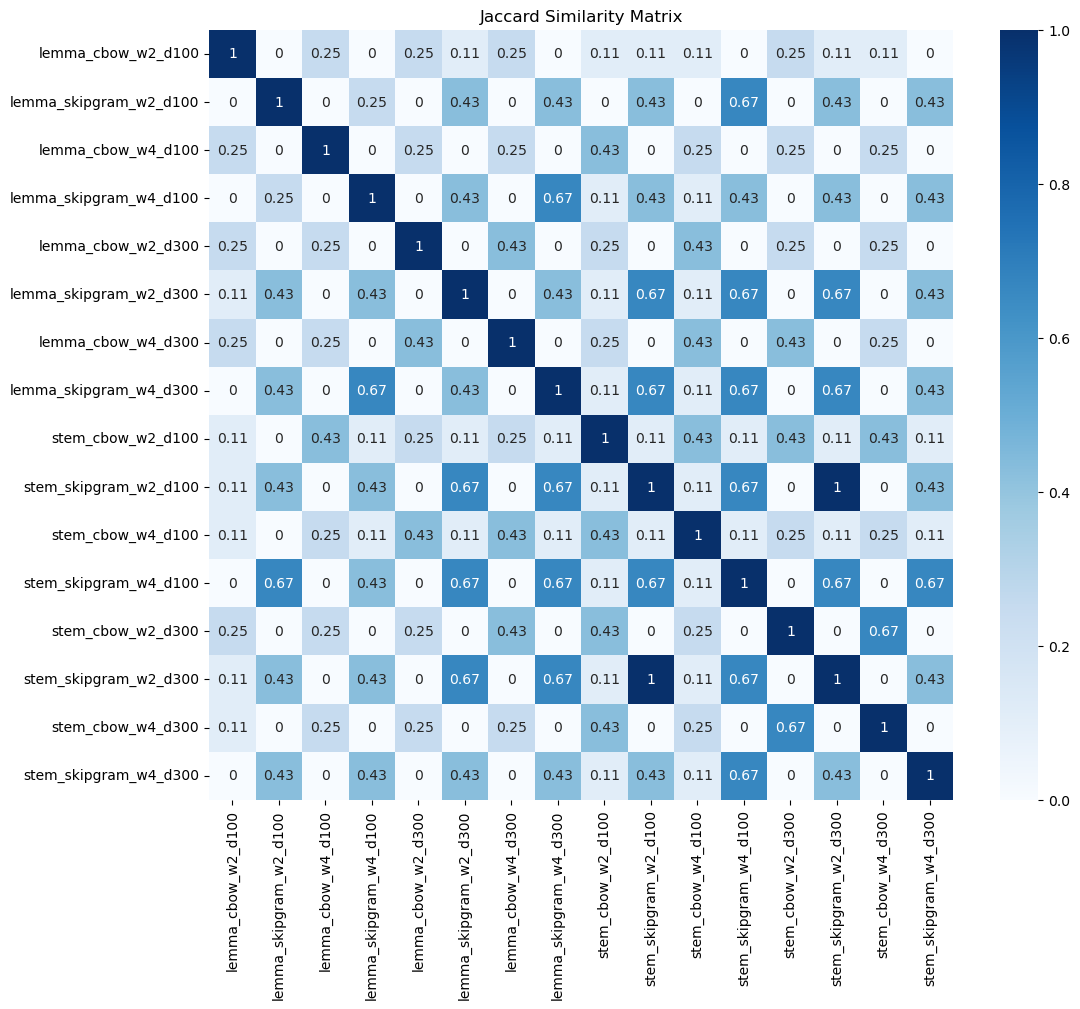

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    jaccard_matrix.astype(float),
    annot=True,
    cmap="Blues"
)

plt.title("Jaccard Similarity Matrix")
plt.show()

In [33]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'HAM VERİ CLS XLS', 'ham_veri.csv', 'lemmatized_veri.csv', 'NLP-ÖDEV1-ÜRÜN YORUMLARI.ipynb', 'stemmed_veri.csv']


In [37]:
jaccard_matrix.to_csv(
    "jaccard_matrix.csv",
    encoding="utf-8-sig"
)

print("Jaccard matrisi kaydedildi.")

Jaccard matrisi kaydedildi.


In [39]:
import os

os.makedirs("models", exist_ok=True)

for name, model in models.items():
    model.save(f"models/{name}.model")

for name, model in stem_models.items():
    model.save(f"models/{name}.model")

print("16 model models klasörüne kaydedildi.")

16 model models klasörüne kaydedildi.


In [41]:
cosine_rows = []

for name, results in similarity_results.items():
    scores = [score for idx, score in results]
    indexes = [idx for idx, score in results]

    cosine_rows.append({
        "Model Adı": name,
        "Benzer Metin Indexleri": indexes,
        "Cosine Skorları": [round(s, 4) for s in scores],
        "Ortalama Cosine": round(sum(scores) / len(scores), 4)
    })

cosine_df = pd.DataFrame(cosine_rows)
cosine_df

,Model Adı,Benzer Metin Indexleri,Cosine Skorları,Ortalama Cosine
0,lemma_cbow_w2_d100,"[6991, 2473, 752, 9667, 5889]","[0.995, 0.9949, 0.9949, 0.9947, 0.9941]",0.9947
1,lemma_skipgram_w2_d100,"[3246, 2643, 3497, 636, 2403]","[0.9902, 0.9888, 0.9885, 0.9879, 0.9877]",0.9886
2,lemma_cbow_w4_d100,"[4684, 2473, 6991, 5296, 3112]","[0.9959, 0.9957, 0.9953, 0.9949, 0.9947]",0.9953
3,lemma_skipgram_w4_d100,"[329, 3246, 2740, 6284, 2643]","[0.9826, 0.9825, 0.9824, 0.9823, 0.9812]",0.9822
4,lemma_cbow_w2_d300,"[4684, 1116, 2473, 506, 9667]","[0.997, 0.9967, 0.9964, 0.9963, 0.996]",0.9965
5,lemma_skipgram_w2_d300,"[2643, 3246, 2740, 5889, 3497]","[0.9899, 0.9898, 0.9886, 0.9883, 0.9876]",0.9889
6,lemma_cbow_w4_d300,"[4684, 506, 752, 2473, 8245]","[0.9981, 0.998, 0.9973, 0.9971, 0.9971]",0.9975
7,lemma_skipgram_w4_d300,"[3246, 2740, 2403, 329, 2643]","[0.9864, 0.9859, 0.9853, 0.9846, 0.9837]",0.9852
8,stem_cbow_w2_d100,"[5296, 2740, 2473, 4684, 1032]","[0.9951, 0.9948, 0.9948, 0.9948, 0.9942]",0.9947
9,stem_skipgram_w2_d100,"[2740, 5889, 2643, 2403, 3246]","[0.9892, 0.9885, 0.9884, 0.9877, 0.9873]",0.9882


In [43]:
cosine_df.to_csv("cosine_sonuclari.csv", index=False, encoding="utf-8-sig")
print("Cosine sonuçları kaydedildi.")

Cosine sonuçları kaydedildi.


In [45]:
jaccard_matrix.to_csv("jaccard_matrix.csv", encoding="utf-8-sig")
print("Jaccard matrisi kaydedildi.")

Jaccard matrisi kaydedildi.
